# Tree-traversal execution backends: graph vs XLA vs native vs JAX

treeflow accelerates two tree traversals with hand-rolled native C++ ops (the
phylogenetic likelihood and the node-height ratio transform). Writing a C++
kernel **and its gradient** for every new traversal does not scale, and a C++
kernel cannot host arbitrary differentiable per-node functions such as
**neural-network building blocks** (Tree-LSTM / message passing).

This notebook benchmarks the execution strategies for a *generic* differentiable
tree-traversal combinator, to decide where each is worth it:

| backend | what it is |
|---|---|
| **graph** | the traversal as a `tf.while_loop`, run under `@tf.function` (no XLA) |
| **XLA** | the same `tf.while_loop`, run under `tf.function(jit_compile=True)` |
| **unrolled** | the traversal unrolled into a straight-line graph for the (static) topology, optionally `jit_compile`d |
| **native** | the existing hand-written C++ op (only the two ops that have one) |
| **JAX** | `jax.lax.scan` over the topological order, `jax.jit` + `jax.grad` (runs only if JAX is importable) |
| **reference** | `treeflow` implementations as at `v0.0.4` using `TensorArray` and `autograd`

across three per-node operations: a **simple affine** map (the ratio transform),
a **simple multilinear** map (the Felsenstein partial likelihood) — both with a
native op for a ceiling — and an **NN message-passing** block whose hidden width
we sweep to expose where per-node FLOPs dominate the traversal overhead.

The `tf.while_loop` drivers below double as a prototype of the candidate generic
combinator: they take an arbitrary per-node callable and differentiate
automatically.

## 1. Setup

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
%matplotlib inline

# Optional JAX: the JAX cells run only if this import succeeds.
try:
    import jax
    import jax.numpy as jnp
    from jax import lax
    jax.config.update("jax_enable_x64", True)  # match TF float64 for parity
    HAVE_JAX = True
    print("JAX", jax.__version__, "devices:", jax.devices())
except Exception as e:  # pragma: no cover - environment dependent
    HAVE_JAX = False
    print("JAX not available -> JAX cells will be skipped (", type(e).__name__, ")")

DT = tf.float64
NPDT = np.float64

# Quick mode keeps the notebook fast enough to run in CI; raise for real numbers.
QUICK = False
TAXA = [16, 64, 256] if QUICK else [16, 64, 256, 512, 1024]
REPLICATES = 25 if QUICK else 100
SITES = 128          # batch axis for the likelihood (alignment sites)
SAMPLES = 64         # batch axis for the NN op (e.g. posterior samples)
STATES = 4           # nucleotides
NN_WIDTH = 32        # default hidden width for the taxa sweep
NN_WIDTHS = [8, 32, 128]   # width sweep at fixed taxa
NN_WIDTH_TAXA = 128
# Unrolled+XLA compile cost grows with node count; cap it.
MAX_UNROLL_XLA_NODES = 130 if QUICK else 260
print("TF", tf.__version__, "| threads:",
      tf.config.threading.get_intra_op_parallelism_threads(), "intra")

/Users/christiaanswanepoel/.pyenv/versions/3.11.12/envs/treeflow/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


JAX 0.10.1 devices: [CpuDevice(id=0)]
TF 2.20.0 | threads: 0 intra


JAX 0.10.1 devices: [CpuDevice(id=0)]
TF 2.21.0 | threads: 0 intra


## 2. Timing harness

`bench(f)` records the steady-state per-call time (mean over `REPLICATES` after a
warm-up) and, separately, the **first-call** time (tracing + XLA compile), which
matters because it is paid again whenever the topology changes. `force` blocks on
TF or JAX results so we time real compute, not async dispatch.

In [2]:
results = []  # one row per (operation, backend, size, metric)

def to_dense(g):
    "Densify a possibly-sparse gradient (tf.gather yields IndexedSlices)."
    g = tf.convert_to_tensor(g) if isinstance(g, tf.IndexedSlices) else g
    return g.numpy()

def force(o):
    if isinstance(o, (list, tuple)):
        for x in o:
            force(x)
    elif o is None:
        return
    elif isinstance(o, tf.IndexedSlices):
        o.values.numpy()
    elif hasattr(o, "numpy"):
        o.numpy()
    elif hasattr(o, "block_until_ready"):
        o.block_until_ready()

def bench(f, replicates=REPLICATES):
    "Return (steady_per_call_s, first_call_s). f() returns forceable outputs."
    t0 = time.perf_counter(); force(f()); first = time.perf_counter() - t0
    t0 = time.perf_counter()
    for _ in range(replicates):
        out = f()
    force(out)
    steady = (time.perf_counter() - t0) / replicates
    return steady, first

def record(operation, backend, size, fwd, vg, compile_s, err="", maxdiff=np.nan, warning=""):
    # `error` is a hard failure (exception / failed compile, no timing); `warning`
    # is a numerical issue (grad mismatch / nan gradients) where the timing is still
    # valid and kept by the downstream plots/tables.
    results.append(dict(operation=operation, backend=backend, size=size,
                        forward_ms=fwd * 1e3 if fwd == fwd else np.nan,
                        value_grad_ms=vg * 1e3 if vg == vg else np.nan,
                        compile_ms=compile_s * 1e3 if compile_s == compile_s else np.nan,
                        max_grad_diff=maxdiff, error=err, warning=warning))

def make_tf_forward(callable_, jit):
    return tf.function(callable_, jit_compile=jit)

def make_tf_value_and_grad(loss_callable, variables, jit):
    @tf.function(jit_compile=jit)
    def vg():
        with tf.GradientTape() as tape:
            for v in variables:
                tape.watch(v)
            L = loss_callable()
        return L, tape.gradient(L, variables)
    return vg

## 3. Topology and the generic traversal drivers

`random_topology` builds a random binary tree (same children-before-parents id
convention as treeflow) and returns the index vectors the traversals need. The
`tf_postorder` / `tf_preorder` drivers carry the node states in a single tensor
and update one node per step with `tensor_scatter_nd_update` (no `TensorArray`,
so XLA lowers it cleanly); `maximum_iterations` is set statically so the reverse
pass compiles. The `*_unrolled` variants build a straight-line graph for the
fixed topology. Each driver takes an arbitrary per-node `node_fn`.

In [3]:
def random_topology(leaf_count, seed=0):
    "Random binary topology; returns python/np + tf index vectors."
    from treeflow.tree.topology.numpy_tree_topology import NumpyTreeTopology
    from treeflow.tree.topology.tensorflow_tree_topology import numpy_topology_to_tensor
    rng = np.random.default_rng(seed)
    node_count = 2 * leaf_count - 1
    parent = np.full(node_count, -1, np.int32)
    active = list(range(leaf_count)); nxt = leaf_count
    while len(active) > 1:
        a = active.pop(rng.integers(len(active)))
        b = active.pop(rng.integers(len(active)))
        parent[a] = nxt; parent[b] = nxt; active.append(nxt); nxt += 1
    parent = parent[:-1]  # drop root (-1), matching treeflow's parent_indices
    topo = numpy_topology_to_tensor(NumpyTreeTopology(parent_indices=parent))
    tc = leaf_count
    pre = (topo.preorder_node_indices - tc).numpy().astype(np.int32)  # internal-space, root first
    par = (topo.parent_indices[tc:] - tc).numpy().astype(np.int32)    # parent internal id
    post = topo.postorder_node_indices.numpy().astype(np.int32)       # full node ids
    child = topo.node_child_indices.numpy().astype(np.int32)          # [n_internal, 2] full ids
    return dict(topology=topo, leaf_count=leaf_count, node_count=node_count,
                n_internal=leaf_count - 1, pre=pre, par=par, post=post, child=child,
                pre_t=tf.constant(pre), par_t=tf.constant(par),
                post_t=tf.constant(post), child_t=tf.constant(child))

# ---- TF while_loop drivers (loop-carried tensor + scatter; XLA-friendly) ----
def tf_postorder(order_t, child_t, leaf_state, n_internal, node_fn):
    tail = tf.shape(leaf_state)[1:]
    st0 = tf.concat([leaf_state,
                     tf.zeros(tf.concat([[n_internal], tail], 0), leaf_state.dtype)], 0)
    def body(k, st):
        node = order_t[k]; ch = child_t[k]
        new = node_fn(tf.gather(st, ch), ch, node)
        return (k + 1, tf.tensor_scatter_nd_update(st, [[node]], [new]))
    _, st = tf.while_loop(lambda k, st: k < n_internal, body,
                          (tf.constant(0), st0), maximum_iterations=n_internal)
    return st

def tf_preorder(order_t, par_t, root_state, n_internal, node_fn):
    def body(k, st):
        i = order_t[k]; p = par_t[i]
        return (k + 1, tf.tensor_scatter_nd_update(st, [[i]], [node_fn(st[p], i)]))
    _, st = tf.while_loop(lambda k, st: k < n_internal, body,
                          (tf.constant(1), root_state), maximum_iterations=n_internal - 1)
    return st

# ---- TF unrolled drivers (straight-line graph for the fixed topology) ----
def tf_postorder_unrolled(order_np, child_np, leaf_states, node_fn, node_count):
    vals = [None] * node_count
    for i, v in enumerate(leaf_states):
        vals[i] = v
    for k in range(len(order_np)):
        node = int(order_np[k]); ch = child_np[k]
        cst = tf.stack([vals[int(c)] for c in ch])
        vals[node] = node_fn(cst, tf.constant(ch), node)
    return vals

def tf_preorder_unrolled(order_np, par_np, root_value, node_fn, n_internal):
    vals = [None] * n_internal
    vals[int(order_np[0])] = root_value
    for k in range(1, n_internal):
        i = int(order_np[k]); p = par_np[i]
        vals[i] = node_fn(vals[p], i)
    return tf.stack(vals)

## 4. JAX drivers (optional)

In [4]:
if HAVE_JAX:
    def jax_postorder(order, child, leaf_state, n_internal, node_fn):
        st0 = jnp.concatenate(
            [leaf_state, jnp.zeros((n_internal,) + leaf_state.shape[1:], leaf_state.dtype)], 0)
        def step(st, k):
            node = order[k]; ch = child[k]
            return st.at[node].set(node_fn(st[ch], ch, node)), None
        st, _ = lax.scan(step, st0, jnp.arange(n_internal))
        return st

    def jax_preorder(order, par, root_state, n_internal, node_fn):
        def step(st, k):
            i = order[k]; p = par[i]
            return st.at[i].set(node_fn(st[p], i)), None
        st, _ = lax.scan(step, root_state, jnp.arange(1, n_internal))
        return st
    print("JAX drivers defined")
else:
    print("Skipping JAX drivers")

JAX drivers defined


## 5. Operation 1 — node-height ratio transform (simple, affine, preorder)

`h[i] = (h[parent] - anchor[i]) * ratio[i] + anchor[i]`. A few flops per node, so
the traversal *overhead* dominates — the regime where the native op wins most.
Backends are checked against the treeflow reference before timing; the gradient
is taken w.r.t. the ratios.

In [5]:
from treeflow.traversal.ratio_transform import ratios_to_node_heights as ref_ratio
from treeflow.acceleration.native import native_ratios_to_node_heights

def ratio_problem(p, seed=1):
    rng = np.random.default_rng(seed)
    N = p["n_internal"]
    ratios = np.concatenate([rng.uniform(0.1, 0.9, N - 1), [rng.uniform(1.0, 3.0)]]).astype(NPDT)
    anchor = rng.uniform(0.0, 0.5, N).astype(NPDT)
    return tf.constant(ratios), tf.constant(anchor)

def run_ratio(p):
    N = p["n_internal"]
    ratios, anchor = ratio_problem(p)
    pre_t, par_t = p["pre_t"], p["par_t"]
    pre_np, par_np = p["pre"], p["par"]
    w = tf.range(1, N + 1, dtype=DT)

    def node_fn(parent_h, i):
        return (parent_h - anchor[i]) * ratios[i] + anchor[i]

    def root_state(r, a):
        root = pre_t[0]
        return tf.tensor_scatter_nd_update(tf.zeros_like(r), [[root]], [r[root] + a[root]])

    # forward callables (close over fresh Variables for the vg variants)
    def fwd_reference(): return ref_ratio(pre_t, par_t, ratios, anchor)
    def fwd_native():    return native_ratios_to_node_heights(pre_t, par_t, ratios, anchor)
    def fwd_whileloop(): return tf_preorder(pre_t, par_t, root_state(ratios, anchor), N, node_fn)
    def fwd_unrolled():
        return tf_preorder_unrolled(
            pre_np, par_np, ratios[int(pre_np[0])] + anchor[int(pre_np[0])], node_fn, N)

    ref_val = fwd_reference().numpy()
    # gradient reference (w.r.t. ratios) via the treeflow reference
    rv = tf.Variable(ratios)
    with tf.GradientTape() as t:
        L = tf.reduce_sum(ref_ratio(pre_t, par_t, rv, anchor) * w)
    ref_grad = t.gradient(L, rv).numpy()

    def loss_from(forward, r, a):
        # rebuild closures bound to Variables r, a
        def node_fn2(parent_h, i): return (parent_h - a[i]) * r[i] + a[i]
        if forward == "whileloop":
            root = tf.tensor_scatter_nd_update(tf.zeros_like(r), [[pre_t[0]]], [r[pre_t[0]] + a[pre_t[0]]])
            h = tf_preorder(pre_t, par_t, root, N, node_fn2)
        elif forward == "unrolled":
            h = tf_preorder_unrolled(pre_np, par_np, r[int(pre_np[0])] + a[int(pre_np[0])], node_fn2, N)
        elif forward == "reference":
            h = ref_ratio(pre_t, par_t, r, a)
        elif forward == "native":
            h = native_ratios_to_node_heights(pre_t, par_t, r, a)
        return tf.reduce_sum(h * w)

    backends = [
        ("reference", fwd_reference, "reference", False),
        ("native",    fwd_native,    "native",    False),
        ("graph",     fwd_whileloop, "whileloop", False),
        ("XLA",       fwd_whileloop, "whileloop", True),
        ("unrolled",  fwd_unrolled,  "unrolled",  False),
        ("unrolled+XLA", fwd_unrolled, "unrolled", True),
    ]
    for name, fwd_callable, kind, jit in backends:
        if name == "unrolled+XLA" and p["node_count"] > MAX_UNROLL_XLA_NODES:
            continue
        try:
            warn = ""
            fwd_fn = make_tf_forward(fwd_callable, jit)
            val = fwd_fn(); force(val)
            assert np.allclose(val.numpy(), ref_val, rtol=1e-9, atol=1e-9), "forward mismatch"
            fwd_s, _ = bench(fwd_fn)
            rv2 = tf.Variable(ratios); av2 = tf.Variable(anchor)
            vg_fn = make_tf_value_and_grad(lambda: loss_from(kind, rv2, av2), [rv2, av2], jit)
            _, grads = vg_fn(); force(grads)
            # Robust grad check: nan-safe max diff, recorded as a warning (not asserted)
            # so the timing survives a numerical mismatch / underflow.
            diff = np.abs(to_dense(grads[0]) - ref_grad)
            nan_frac = float(np.mean(np.isnan(diff)))
            md_ = float(np.nanmax(diff))
            if not (md_ < 1e-6):
                warn += f"grad mismatch {md_:.2g}; "
            if nan_frac > 0:
                warn += f"nan frac {nan_frac:.2f}; "
            vg_s, comp_s = bench(vg_fn)
            record("ratio", name, p["leaf_count"], fwd_s, vg_s, comp_s, maxdiff=md_, warning=warn)
        except Exception as e:
            record("ratio", name, p["leaf_count"], np.nan, np.nan, np.nan, err=f"{type(e).__name__}: {e}")

    if HAVE_JAX:
        try:
            warn = ""
            r_j = jnp.asarray(ratios.numpy()); a_j = jnp.asarray(anchor.numpy())
            pre_j = jnp.asarray(pre_np); par_j = jnp.asarray(par_np); w_j = jnp.asarray(w.numpy())
            def run_j(r):
                def nf(parent_h, i): return (parent_h - a_j[i]) * r[i] + a_j[i]
                root0 = jnp.zeros_like(r).at[pre_j[0]].set(r[pre_j[0]] + a_j[pre_j[0]])
                return jax_preorder(pre_j, par_j, root0, N, nf)
            fwd_j = jax.jit(run_j)
            v = fwd_j(r_j); force(v)
            assert np.allclose(np.asarray(v), ref_val, rtol=1e-9, atol=1e-9)
            fwd_s, _ = bench(lambda: fwd_j(r_j))
            vg_j = jax.jit(jax.value_and_grad(lambda r: jnp.sum(run_j(r) * w_j)))
            _, g = vg_j(r_j); force((_, g))
            diff = np.abs(np.asarray(g) - ref_grad)
            nan_frac = float(np.mean(np.isnan(diff)))
            md_ = float(np.nanmax(diff))
            if not (md_ < 1e-6):
                warn += f"grad mismatch {md_:.2g}; "
            if nan_frac > 0:
                warn += f"nan frac {nan_frac:.2f}; "
            vg_s, comp_s = bench(lambda: vg_j(r_j))
            record("ratio", "JAX", p["leaf_count"], fwd_s, vg_s, comp_s, maxdiff=md_, warning=warn)
        except Exception as e:
            record("ratio", "JAX", p["leaf_count"], np.nan, np.nan, np.nan, err=f"{type(e).__name__}: {e}")

for lc in TAXA:
    run_ratio(random_topology(lc, seed=lc))
print("ratio done")
pd.DataFrame([r for r in results if r["operation"] == "ratio"])[
    ["backend", "size", "value_grad_ms", "compile_ms", "max_grad_diff", "warning", "error"]]

Silencing TensorFlow...


I0000 00:00:1781479249.235373 37130984 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ratio done


,backend,size,value_grad_ms,compile_ms,max_grad_diff,warning,error
0,reference,16,0.451895,1.152916,0.000000e+00,,
1,native,16,0.079763,0.175125,7.105427e-15,,
2,graph,16,0.493958,1.713792,0.000000e+00,,
3,XLA,16,0.064326,0.216125,3.552714e-15,,
4,unrolled,16,0.281490,0.338208,0.000000e+00,,
5,unrolled+XLA,16,0.058526,0.224500,7.105427e-15,,
6,JAX,16,0.005192,0.025667,7.105427e-15,,
7,reference,64,1.407579,3.776375,0.000000e+00,,
8,native,64,0.083076,0.098542,1.421085e-14,,
9,graph,64,1.450079,4.122542,0.000000e+00,,


## 6. Operation 2 — Felsenstein partial likelihood (simple, multilinear, postorder)

`partial[node] = prod_children (P_child @ child_partial)`, batched over alignment
sites. More per-node compute than the ratio transform (an `S x S` matvec per
child), and a native op exists. Gradient w.r.t. the transition matrices.

In [6]:
from treeflow.traversal.phylo_likelihood import phylogenetic_likelihood as ref_like
from treeflow.acceleration.native import native_phylogenetic_likelihood

def like_problem(p, seed=3):
    rng = np.random.default_rng(seed)
    L = p["leaf_count"]; S = STATES; B = SITES
    states = rng.integers(0, S, size=(B, L))
    seq = tf.constant(np.eye(S)[states], DT)                      # [B, L, S]
    P = rng.uniform(0.1, 1.0, (p["node_count"], S, S)); P /= P.sum(-1, keepdims=True)
    P = tf.constant(P, DT)
    freq = tf.constant(np.full(S, 1.0 / S), DT)
    return seq, P, freq

def run_like(p):
    L = p["leaf_count"]; S = STATES
    seq, P, freq = like_problem(p)
    post_t, child_t = p["post_t"], p["child_t"]
    post_np, child_np = p["post"], p["child"]
    leaf_state = tf.transpose(seq, [1, 0, 2])                     # [L, B, S]
    topo = p["topology"]

    def node_fn(child_states, child_ids, node):
        Pc = tf.gather(P, child_ids)                              # [nc, S, S]
        contrib = tf.einsum("csj,cbj->cbs", Pc, child_states)     # [nc, B, S]
        return tf.reduce_prod(contrib, 0)                         # [B, S]

    def fwd_reference():
        return ref_like(seq, tf.expand_dims(P, 0), freq,
                        topo.postorder_node_indices, topo.node_child_indices,
                        batch_shape=tf.shape(seq)[:1])
    def fwd_native():
        return native_phylogenetic_likelihood(
            seq, tf.expand_dims(P, 0), freq,
            topo.postorder_node_indices, topo.node_child_indices)
    def fwd_whileloop():
        st = tf_postorder(post_t, child_t, leaf_state, p["n_internal"], node_fn)
        return tf.reduce_sum(freq * st[-1], -1)
    def fwd_unrolled():
        vals = tf_postorder_unrolled(post_np, child_np, tf.unstack(leaf_state), node_fn, p["node_count"])
        return tf.reduce_sum(freq * vals[-1], -1)

    ref_val = fwd_reference().numpy()
    Pv = tf.Variable(P)
    with tf.GradientTape() as t:
        L_ = tf.reduce_sum(tf.math.log(ref_like(
            seq, tf.expand_dims(Pv, 0), freq, topo.postorder_node_indices,
            topo.node_child_indices, batch_shape=tf.shape(seq)[:1])))
    ref_grad = t.gradient(L_, Pv).numpy()

    def loss_from(kind, Pvar):
        def node_fn2(child_states, child_ids, node):
            Pc = tf.gather(Pvar, child_ids)
            return tf.reduce_prod(tf.einsum("csj,cbj->cbs", Pc, child_states), 0)
        if kind == "whileloop":
            st = tf_postorder(post_t, child_t, leaf_state, p["n_internal"], node_fn2)
            sl = tf.reduce_sum(freq * st[-1], -1)
        elif kind == "unrolled":
            vals = tf_postorder_unrolled(post_np, child_np, tf.unstack(leaf_state), node_fn2, p["node_count"])
            sl = tf.reduce_sum(freq * vals[-1], -1)
        elif kind == "reference":
            sl = ref_like(seq, tf.expand_dims(Pvar, 0), freq, topo.postorder_node_indices,
                          topo.node_child_indices, batch_shape=tf.shape(seq)[:1])
        elif kind == "native":
            sl = native_phylogenetic_likelihood(seq, tf.expand_dims(Pvar, 0), freq,
                                                topo.postorder_node_indices, topo.node_child_indices)
        return tf.reduce_sum(tf.math.log(sl))

    backends = [
        ("reference", fwd_reference, "reference", False),
        ("native",    fwd_native,    "native",    False),
        ("graph",     fwd_whileloop, "whileloop", False),
        ("XLA",       fwd_whileloop, "whileloop", True),
        ("unrolled",  fwd_unrolled,  "unrolled",  False),
        ("unrolled+XLA", fwd_unrolled, "unrolled", True),
    ]
    for name, fwd_callable, kind, jit in backends:
        if name == "unrolled+XLA" and p["node_count"] > MAX_UNROLL_XLA_NODES:
            continue
        try:
            warn = ""
            fwd_fn = make_tf_forward(fwd_callable, jit)
            val = fwd_fn(); force(val)
            assert np.allclose(val.numpy(), ref_val, rtol=1e-8, atol=1e-10), "forward mismatch"
            fwd_s, _ = bench(fwd_fn)
            Pv2 = tf.Variable(P)
            vg_fn = make_tf_value_and_grad(lambda: loss_from(kind, Pv2), [Pv2], jit)
            _, grads = vg_fn(); force(grads)
            # Robust grad check: nan-safe max diff, recorded as a warning (not asserted)
            # so the timing survives a numerical mismatch / underflow.
            diff = np.abs(to_dense(grads[0]) - ref_grad)
            nan_frac = float(np.mean(np.isnan(diff)))
            md_ = float(np.nanmax(diff))
            if not (md_ < 1e-5):
                warn += f"grad mismatch {md_:.2g}; "
            if nan_frac > 0:
                warn += f"nan frac {nan_frac:.2f}; "
            vg_s, comp_s = bench(vg_fn)
            record("likelihood", name, p["leaf_count"], fwd_s, vg_s, comp_s, maxdiff=md_, warning=warn)
        except Exception as e:
            record("likelihood", name, p["leaf_count"], np.nan, np.nan, np.nan, err=f"{type(e).__name__}: {e}")

    if HAVE_JAX:
        try:
            warn = ""
            P_j = jnp.asarray(P.numpy()); freq_j = jnp.asarray(freq.numpy())
            leaf_j = jnp.asarray(leaf_state.numpy())
            post_j = jnp.asarray(post_np); child_j = jnp.asarray(child_np)
            def run_j(Pp):
                def nf(child_states, child_ids, node):
                    Pc = Pp[child_ids]
                    return jnp.prod(jnp.einsum("csj,cbj->cbs", Pc, child_states), 0)
                st = jax_postorder(post_j, child_j, leaf_j, p["n_internal"], nf)
                return jnp.sum(freq_j * st[-1], -1)
            fwd_j = jax.jit(run_j)
            v = fwd_j(P_j); force(v)
            assert np.allclose(np.asarray(v), ref_val, rtol=1e-8, atol=1e-10)
            fwd_s, _ = bench(lambda: fwd_j(P_j))
            vg_j = jax.jit(jax.value_and_grad(lambda Pp: jnp.sum(jnp.log(run_j(Pp)))))
            _, g = vg_j(P_j); force((_, g))
            diff = np.abs(np.asarray(g) - ref_grad)
            nan_frac = float(np.mean(np.isnan(diff)))
            md_ = float(np.nanmax(diff))
            if not (md_ < 1e-5):
                warn += f"grad mismatch {md_:.2g}; "
            if nan_frac > 0:
                warn += f"nan frac {nan_frac:.2f}; "
            vg_s, comp_s = bench(lambda: vg_j(P_j))
            record("likelihood", "JAX", p["leaf_count"], fwd_s, vg_s, comp_s, maxdiff=md_, warning=warn)
        except Exception as e:
            record("likelihood", "JAX", p["leaf_count"], np.nan, np.nan, np.nan, err=f"{type(e).__name__}: {e}")

for lc in TAXA:
    run_like(random_topology(lc, seed=lc))
print("likelihood done")
pd.DataFrame([r for r in results if r["operation"] == "likelihood"])[
    ["backend", "size", "value_grad_ms", "compile_ms", "max_grad_diff", "warning", "error"]]

/var/folders/3x/bn65bn1d7p367pwy6m54pjdh0000gn/T/ipykernel_63821/798463997.py:90: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(to_dense(grads[0]) - ref_grad)
/var/folders/3x/bn65bn1d7p367pwy6m54pjdh0000gn/T/ipykernel_63821/798463997.py:120: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(np.asarray(g) - ref_grad)


likelihood done


,backend,size,value_grad_ms,compile_ms,max_grad_diff,warning,error
0,reference,16,0.877277,1.860708,0.000000e+00,,
1,native,16,0.166965,0.234208,3.552714e-14,,
2,graph,16,0.528104,1.147375,3.552714e-14,,
3,XLA,16,0.253897,0.443000,3.552714e-14,,
4,unrolled,16,0.279083,0.314250,3.552714e-14,,
5,unrolled+XLA,16,0.182855,0.330417,3.552714e-14,,
6,JAX,16,0.161276,0.182875,3.552714e-14,,
7,reference,64,3.267589,4.353542,0.000000e+00,,
8,native,64,0.234474,0.299459,2.842171e-14,,
9,graph,64,6.410753,7.396792,5.684342e-14,,


## 7. Operation 3 — NN message passing (Tree-NN, postorder)

Each internal node embeds its children:
`h[node] = tanh(W2 . relu(W1 . [sum(child h); node_features] + b1) + b2)`.
This is the use case a C++ kernel **cannot** host. We sweep the hidden width to
show the crossover: once the per-node matmuls dominate, graph/XLA/JAX converge
(the traversal skeleton stops mattering). Gradient w.r.t. the shared weights.

In [7]:
def nn_params(H, seed=0):
    rng = np.random.default_rng(seed)
    return [tf.Variable(tf.constant(rng.standard_normal((2 * H, H)) * 0.1, DT)),
            tf.Variable(tf.zeros(H, DT)),
            tf.Variable(tf.constant(rng.standard_normal((H, H)) * 0.1, DT)),
            tf.Variable(tf.zeros(H, DT))]

def run_nn(p, H, sweep_key, sweep_val):
    rng = np.random.default_rng(7)
    n_leaf = p["leaf_count"]; nodes = p["node_count"]
    leaf_h = tf.constant(rng.standard_normal((n_leaf, SAMPLES, H)), DT)   # [leaf, B, H]
    feat = tf.constant(rng.standard_normal((nodes, H)), DT)               # [node, H]
    P = nn_params(H)
    post_t, child_t = p["post_t"], p["child_t"]
    post_np, child_np = p["post"], p["child"]

    def make_node_fn(P):
        W1, b1, W2, b2 = P
        def node_fn(child_states, child_ids, node):
            csum = tf.reduce_sum(child_states, 0)                         # [B, H]
            x = tf.concat([csum, tf.broadcast_to(feat[node], tf.shape(csum))], -1)
            return tf.tanh(tf.matmul(tf.nn.relu(tf.matmul(x, W1) + b1), W2) + b2)
        return node_fn

    def forward(P, kind):
        node_fn = make_node_fn(P)
        if kind == "whileloop":
            st = tf_postorder(post_t, child_t, leaf_h, p["n_internal"], node_fn)
            return st[-1]
        else:
            vals = tf_postorder_unrolled(post_np, child_np, tf.unstack(leaf_h), node_fn, nodes)
            return vals[-1]

    ref_val = forward(P, "whileloop").numpy()
    with tf.GradientTape() as t:
        L = tf.reduce_sum(forward(P, "whileloop") ** 2)
    ref_grad = t.gradient(L, P)[0].numpy()

    backends = [
        ("graph",    "whileloop", False),
        ("XLA",      "whileloop", True),
        ("unrolled", "unrolled",  False),
        ("unrolled+XLA", "unrolled", True),
    ]
    for name, kind, jit in backends:
        if name == "unrolled+XLA" and nodes > MAX_UNROLL_XLA_NODES:
            continue
        try:
            warn = ""
            fwd_fn = make_tf_forward(lambda: forward(P, kind), jit)
            val = fwd_fn(); force(val)
            assert np.allclose(val.numpy(), ref_val, rtol=1e-6, atol=1e-6)
            fwd_s, _ = bench(fwd_fn)
            Pv = nn_params(H)
            vg_fn = make_tf_value_and_grad(lambda: tf.reduce_sum(forward(Pv, kind) ** 2), Pv, jit)
            _, grads = vg_fn(); force(grads)
            # Robust: report the proportion of nan gradient entries (underflow/overflow)
            # as a warning without discarding the timing.
            nan_frac = float(np.mean(np.isnan(to_dense(grads[0]))))
            if nan_frac > 0:
                warn += f"nan frac {nan_frac:.2f}; "
            vg_s, comp_s = bench(vg_fn)
            record("nn", name, sweep_val, fwd_s, vg_s, comp_s, warning=warn)
        except Exception as e:
            record("nn", name, sweep_val, np.nan, np.nan, np.nan, err=f"{type(e).__name__}: {e}")

    if HAVE_JAX:
        try:
            warn = ""
            Pj = [jnp.asarray(x.numpy()) for x in P]
            lh = jnp.asarray(leaf_h.numpy()); ft = jnp.asarray(feat.numpy())
            post_j = jnp.asarray(post_np); child_j = jnp.asarray(child_np)
            def run_j(P):
                W1, b1, W2, b2 = P
                def nf(child_states, child_ids, node):
                    csum = jnp.sum(child_states, 0)
                    x = jnp.concatenate([csum, jnp.broadcast_to(ft[node], csum.shape)], -1)
                    return jnp.tanh(jnp.maximum(x @ W1 + b1, 0.0) @ W2 + b2)
                st = jax_postorder(post_j, child_j, lh, p["n_internal"], nf)
                return st[-1]
            fwd_j = jax.jit(run_j)
            v = fwd_j(Pj); force(v)
            assert np.allclose(np.asarray(v), ref_val, rtol=1e-5, atol=1e-5)
            fwd_s, _ = bench(lambda: fwd_j(Pj))
            vg_j = jax.jit(jax.value_and_grad(lambda P: jnp.sum(run_j(P) ** 2)))
            _, g = vg_j(Pj); force((_, g))
            nan_frac = float(np.mean(np.isnan(np.asarray(g[0]))))
            if nan_frac > 0:
                warn += f"nan frac {nan_frac:.2f}; "
            vg_s, comp_s = bench(lambda: vg_j(Pj))
            record("nn", "JAX", sweep_val, fwd_s, vg_s, comp_s, warning=warn)
        except Exception as e:
            record("nn", "nn-JAX", sweep_val, np.nan, np.nan, np.nan, err=f"{type(e).__name__}: {e}")

# Taxa sweep at the default width
for lc in TAXA:
    run_nn(random_topology(lc, seed=lc), NN_WIDTH, "taxa", lc)
print("nn taxa sweep done")
# Width sweep at a fixed (modest) tree
p_fixed = random_topology(NN_WIDTH_TAXA, seed=NN_WIDTH_TAXA)
for H in NN_WIDTHS:
    run_nn(p_fixed, H, "width", H)
print("nn width sweep done")

nn taxa sweep done
nn width sweep done


## 8. Results

In [8]:
df = pd.DataFrame(results)
df["operation_size"] = df["operation"] + "@" + df["size"].astype(str)
if "warning" not in df:
    df["warning"] = ""
df["warning"] = df["warning"].fillna("")

# Hard failures (exceptions / failed compiles) — no timing recorded; excluded below.
errs = df[df["error"] != ""]
if len(errs):
    print("Backends that errored / did not compile (no timing recorded):")
    display(errs[["operation", "backend", "size", "error"]])
else:
    print("All backends ran with no hard errors.")

# Numerical warnings (grad mismatch / nan gradients) — timing is still valid and
# these rows ARE kept in the plots/tables below.
warns = df[df["warning"] != ""]
if len(warns):
    print("\nBackends with numerical warnings (timing still used):")
    display(warns[["operation", "backend", "size", "warning"]])
else:
    print("No numerical warnings.")

# Correctness summary (max gradient diff vs reference, where checked)
chk = df[df["max_grad_diff"].notna()]
print("\nMax gradient diff vs reference (should be ~0):")
display(chk.groupby(["operation", "backend"])["max_grad_diff"].max().unstack().round(2).fillna("-"))

All backends ran with no hard errors.

Backends with numerical warnings (timing still used):


,operation,backend,size,warning
52,likelihood,reference,512,nan frac 1.00;
53,likelihood,native,512,nan frac 1.00;
54,likelihood,graph,512,nan frac 1.00;
55,likelihood,XLA,512,nan frac 1.00;
56,likelihood,unrolled,512,nan frac 1.00;
57,likelihood,JAX,512,nan frac 1.00;
58,likelihood,reference,1024,nan frac 1.00;
59,likelihood,native,1024,nan frac 1.00;
60,likelihood,graph,1024,nan frac 1.00;
61,likelihood,XLA,1024,nan frac 1.00;



Max gradient diff vs reference (should be ~0):


backend,JAX,XLA,graph,native,reference,unrolled,unrolled+XLA
operation,,,,,,,
likelihood,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0


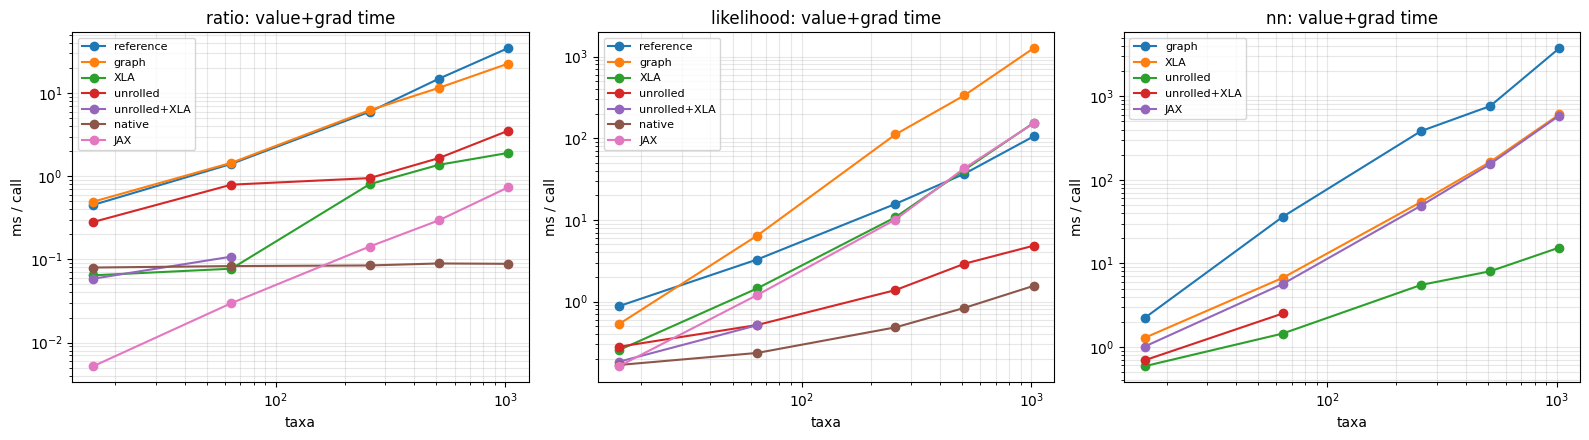

In [9]:
# Value+gradient time vs taxa, per operation (ratio + likelihood have a native ceiling)
ORDER = ["reference", "graph", "XLA", "unrolled", "unrolled+XLA", "native", "JAX"]
def plot_op(op, ax, sweep="taxa"):
    sub = df[(df.operation == op)]
    sub = sub[sub.error == ""]
    if op == "nn":
        sub = sub[sub["size"].isin(TAXA)]  # taxa sweep rows
    for b in ORDER:
        s = sub[sub.backend == b].sort_values("size")
        if len(s):
            ax.plot(s["size"], s["value_grad_ms"], "o-", label=b)
    ax.set_yscale("log"); ax.set_xscale("log")
    ax.set_title(f"{op}: value+grad time"); ax.set_xlabel("taxa"); ax.set_ylabel("ms / call")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_op("ratio", axes[0]); plot_op("likelihood", axes[1]); plot_op("nn", axes[2])
plt.tight_layout(); plt.show()

### Scaling: log-log regression of value+gradient time vs taxa

The curves above are roughly straight on log-log axes, so a power law
`time ≈ c · taxa^b` is a good description. Below we fit
`log10(ms) = intercept + slope·log10(taxa)` per operation × backend; the **slope**
is the empirical scaling exponent (≈1 linear in taxa, ≈2 quadratic), `R²` reports
how well the power law holds, and the dashed lines overlay the fits on the data.

Log-log fit:  log10(value+grad ms) = intercept + slope * log10(taxa)
slope = empirical scaling exponent in taxa; ms_at_1_taxon = 10**intercept



,operation,backend,slope,intercept,ms_at_1_taxon,r2,n
0,ratio,reference,1.05,-1.67,0.0213,0.9920,5
1,ratio,graph,0.93,-1.46,0.0344,0.9973,5
2,ratio,XLA,0.93,-2.47,0.0034,0.9206,5
3,ratio,unrolled,0.54,-1.18,0.0655,0.9305,5
4,ratio,unrolled+XLA,0.44,-1.76,0.0172,1.0000,2
5,ratio,native,0.03,-1.13,0.0741,0.9132,5
6,ratio,JAX,1.17,-3.68,0.0002,0.9991,5
7,likelihood,reference,1.14,-1.49,0.0325,0.9935,5
8,likelihood,graph,1.88,-2.55,0.0028,0.9991,5
9,likelihood,XLA,1.53,-2.53,0.0030,0.9916,5



Scaling exponent (slope) by backend x operation:


operation,likelihood,nn,ratio
backend,,,
reference,1.14,NaN,1.05
graph,1.88,1.73,0.93
XLA,1.53,1.47,0.93
unrolled,0.70,0.79,0.54
unrolled+XLA,0.74,0.93,0.44
native,0.53,NaN,0.03
JAX,1.64,1.52,1.17


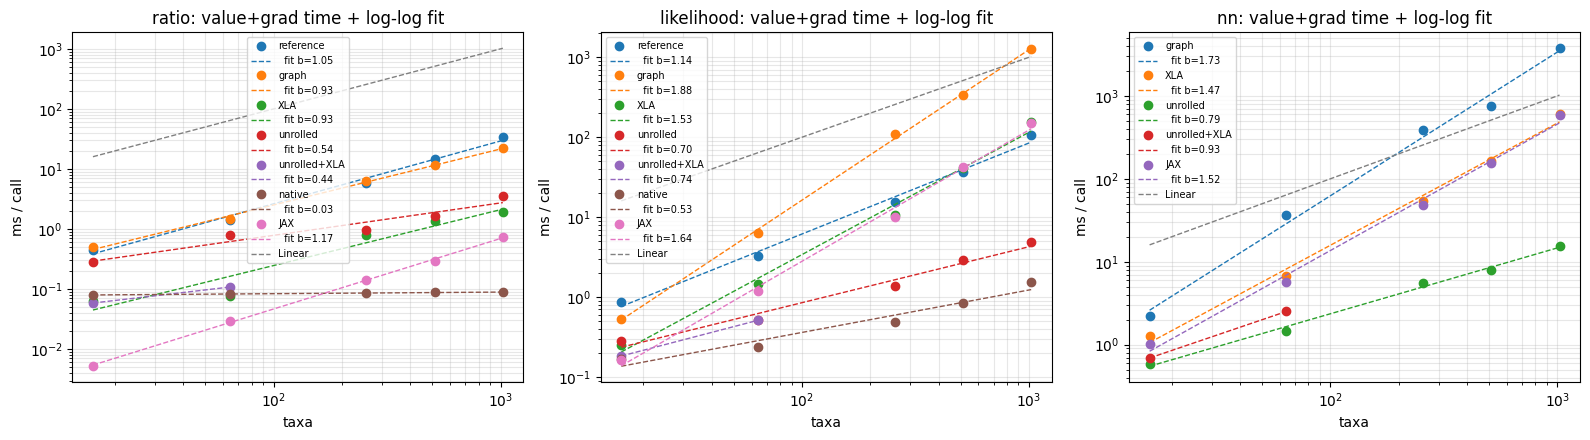

In [13]:
# Log-log regression of the curves above: fit  log10(value+grad ms) = a + b*log10(taxa).
# The slope b is the empirical scaling exponent in the number of taxa (b~1 => linear,
# b~2 => quadratic, ...); 10**a is the extrapolated ms at a single taxon. Fit over the
# taxa sweep only (same rows the plot draws), per operation x backend.
def loglog_fit(op):
    sub = df[(df.operation == op) & (df.error == "")]
    if op == "nn":
        sub = sub[sub["size"].isin(TAXA)]  # taxa sweep rows only
    rows = []
    for b in ORDER:
        s = sub[sub.backend == b].sort_values("size")
        s = s[s["value_grad_ms"].notna() & (s["value_grad_ms"] > 0)]
        if len(s) < 2:
            continue  # need >=2 points to fit a line
        x = np.log10(s["size"].to_numpy(float))
        y = np.log10(s["value_grad_ms"].to_numpy(float))
        slope, intercept = np.polyfit(x, y, 1)
        yhat = slope * x + intercept
        ss_res = float(np.sum((y - yhat) ** 2))
        ss_tot = float(np.sum((y - y.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        rows.append(dict(operation=op, backend=b, slope=slope, intercept=intercept,
                         ms_at_1_taxon=10 ** intercept, r2=r2, n=len(s)))
    return pd.DataFrame(rows)

fit_df = pd.concat([loglog_fit(op) for op in ["ratio", "likelihood", "nn"]],
                   ignore_index=True)

print("Log-log fit:  log10(value+grad ms) = intercept + slope * log10(taxa)")
print("slope = empirical scaling exponent in taxa; ms_at_1_taxon = 10**intercept\n")
display(fit_df.round({"slope": 2, "intercept": 2, "ms_at_1_taxon": 4, "r2": 4}))

# Scaling exponent (slope) laid out backend x operation for a quick comparison.
print("\nScaling exponent (slope) by backend x operation:")
slope_tbl = (fit_df.pivot_table(index="backend", columns="operation", values="slope")
             .reindex(ORDER).dropna(how="all").round(2))
display(slope_tbl)

# Overlay the fitted power laws (dashed) on the measured points to show the fit quality.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, op in zip(axes, ["ratio", "likelihood", "nn"]):
    sub = df[(df.operation == op) & (df.error == "")]
    if op == "nn":
        sub = sub[sub["size"].isin(TAXA)]
    fits = fit_df[fit_df.operation == op].set_index("backend")
    for b in ORDER:
        s = sub[sub.backend == b].sort_values("size")
        s = s[s["value_grad_ms"].notna() & (s["value_grad_ms"] > 0)]
        if not len(s):
            continue
        pts, = ax.plot(s["size"], s["value_grad_ms"], "o", label=b)
        if b in fits.index:
            xx = np.array([s["size"].min(), s["size"].max()], float)
            yy = fits.loc[b, "ms_at_1_taxon"] * xx ** fits.loc[b, "slope"]
            ax.plot(xx, yy, "--", color=pts.get_color(), lw=1,
                    label=f"  fit b={fits.loc[b, 'slope']:.2f}")
    
    ax.plot(xx, xx, "--", color='gray', lw=1,
            label=f"Linear")
    ax.set_yscale("log"); ax.set_xscale("log")
    ax.set_title(f"{op}: value+grad time + log-log fit")
    ax.set_xlabel("taxa"); ax.set_ylabel("ms / call")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

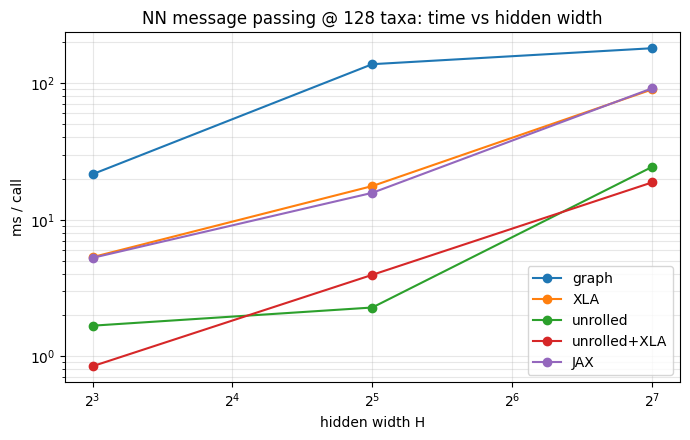

In [11]:
# NN: value+gradient time vs hidden width (the FLOPs-dominate crossover)
fig, ax = plt.subplots(figsize=(7, 4.5))
sub = df[(df.operation == "nn") & (df.error == "") & (df["size"].isin(NN_WIDTHS))]
for b in ["graph", "XLA", "unrolled", "unrolled+XLA", "JAX"]:
    s = sub[sub.backend == b].sort_values("size")
    if len(s):
        ax.plot(s["size"], s["value_grad_ms"], "o-", label=b)
ax.set_yscale("log"); ax.set_xscale("log", base=2)
ax.set_title(f"NN message passing @ {NN_WIDTH_TAXA} taxa: time vs hidden width")
ax.set_xlabel("hidden width H"); ax.set_ylabel("ms / call")
ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [12]:
# Speedup vs the graph-mode while_loop baseline, and vs native where present.
def speedups(op):
    sub = df[(df.operation == op) & (df.error == "")]
    rows = []
    for size, g in sub.groupby("size"):
        base = g[g.backend == "graph"]["value_grad_ms"]
        base = base.iloc[0] if len(base) else np.nan
        nat = g[g.backend == "native"]["value_grad_ms"]
        nat = nat.iloc[0] if len(nat) else np.nan
        for _, r in g.iterrows():
            rows.append(dict(size=size, backend=r.backend, ms=r.value_grad_ms,
                             vs_graph=base / r.value_grad_ms if r.value_grad_ms else np.nan,
                             vs_native=r.value_grad_ms / nat if nat == nat else np.nan))
    return pd.DataFrame(rows)

for op in ["ratio", "likelihood", "nn"]:
    print(f"\n=== {op}: speedup vs graph baseline (and native ceiling) ===")
    t = speedups(op)
    display(t.pivot_table(index="size", columns="backend", values="vs_graph").round(2))

# Compile / first-call times (paid on every retrace / topology change)
print("\n=== first-call (trace+compile) ms, median over sizes ===")
display(df[df.error == ""].groupby(["operation", "backend"])["compile_ms"].median().unstack().round(1).fillna("-"))


=== ratio: speedup vs graph baseline (and native ceiling) ===


backend,JAX,XLA,graph,native,reference,unrolled,unrolled+XLA
size,,,,,,,
16,95.14,7.68,1.0,6.19,1.09,1.75,8.44
64,48.67,18.77,1.0,17.45,1.03,1.83,13.44
256,43.55,7.75,1.0,73.53,1.04,6.55,NaN
512,39.16,8.42,1.0,129.10,0.78,6.99,NaN
1024,30.78,11.83,1.0,254.69,0.65,6.42,NaN



=== likelihood: speedup vs graph baseline (and native ceiling) ===


backend,JAX,XLA,graph,native,reference,unrolled,unrolled+XLA
size,,,,,,,
16,3.27,2.08,1.0,3.16,0.60,1.89,2.89
64,5.34,4.43,1.0,27.34,1.96,12.44,12.52
256,11.02,10.33,1.0,230.30,7.09,80.53,NaN
512,7.81,8.17,1.0,401.04,9.13,115.51,NaN
1024,8.34,8.22,1.0,813.98,12.02,262.18,NaN



=== nn: speedup vs graph baseline (and native ceiling) ===


backend,JAX,XLA,graph,unrolled,unrolled+XLA
size,,,,,
8,4.10,4.05,1.0,12.87,25.49
16,2.20,1.73,1.0,3.78,3.21
32,8.75,7.81,1.0,60.54,34.89
64,6.37,5.38,1.0,25.00,14.39
128,1.97,2.00,1.0,7.40,9.61
256,7.82,7.05,1.0,69.50,NaN
512,4.93,4.66,1.0,94.91,NaN
1024,6.40,6.21,1.0,243.49,NaN



=== first-call (trace+compile) ms, median over sizes ===


backend,JAX,XLA,graph,native,reference,unrolled,unrolled+XLA
operation,,,,,,,
likelihood,10.8,11.7,107.6,0.6,16.2,1.4,0.4
nn,34.9,52.2,155.0,-,-,3.0,2.8
ratio,0.2,0.8,5.8,0.1,7.7,1.1,0.3


## 9. Takeaways

Numbers are hardware/thread dependent (this run: CPU, float64); read the
*shape*, which is consistent across sizes:

- **Ratio (a few flops/node):** traversal overhead dominates, so backend choice
  matters most. The **native** op leads and its margin grows with the tree
  (~4x over the graph `while_loop` at 16 taxa, ~50x at 256). **XLA** beats graph
  by fusing the loop body (~7-19x) but trails native. Strikingly, **JAX**
  `lax.scan` is the fastest here (~90-140x over graph) — for a tiny-state
  sequential recurrence its fused scan + reverse pass is exceptional.

- **Likelihood (an SxS matvec per child):** more per-node work, and the
  **native** op (hand-tuned layout + analytic gradient, parallel over sites)
  dominates at scale (up to ~80x over graph). **XLA** and **JAX** give a modest
  ~3-6x. The generic `while_loop` and `unrolled` drivers are correct but far from
  the bespoke op.

- **NN message passing (the target use case):** as the hidden width grows the
  per-node matmuls dominate and **graph / XLA / JAX converge** — XLA's edge over
  plain graph mode shrinks from ~2.8x (H=8) toward ~2x (H=128), and JAX is
  similar. The backend (and certainly a C++ skeleton) stops mattering because the
  matmuls already run on optimized kernels. `unrolled` is fast but pays a
  per-topology compile cost.

- **Compile / first-call cost** (paid again on every retrace / topology change):
  small for the native op and for XLA on the tiny ops, but tens of ms for the NN
  XLA/JAX paths and for unrolled graphs — generally not an issue except for inference that re-traces
  per tree (i.e. number of taxa changes - not a normal scenario).

**Conclusion for the design question.** A native C++ traversal is worth it only
for the small, fixed numeric kernels (ratio, likelihood) where overhead
dominates and a closed-form gradient exists. For **programmable / NN tree
traversals**, build on a *compiled* combinator — the `tf.while_loop` driver here
under `jit_compile` (or an unrolled-for-fixed-topology variant), or JAX
`lax.scan` — which hosts arbitrary differentiable per-node functions with
automatic gradients and is within a small factor of any native approach once the
node does real work. JAX's scan is notably strong on the tiny recurrences and is
the most ergonomic fit, at the cost of leaving treeflow's TF core.

Follow-up (gated on these results): promote the `tf.while_loop` driver into a
reusable programmable-traversal combinator in `treeflow`, with an optional
unrolled-topology mode, and a worked NN-traversal example.